### Data Acquisition Pipeline

In [1]:
import pydicom

In [2]:
# view dcm properties of a sample image
image_path = 'manifest-1608669183333/Lung-PET-CT-Dx/Lung_Dx-A0001/04-04-2007-NA-Chest-07990/2.000000-5mm-40805/1-01.dcm'

properties = pydicom.dcmread(image_path)
print(properties)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 204
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.14519.5.2.1.6655.2359.911257607240619696148712587012
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.22213.1.143
(0002,0013) Implementation Version Name         SH: '0.5'
(0002,0016) Source Application Entity Title     AE: 'POSDA'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL', 'HELIX']
(0008,0012) Instance Creation Date              DA: '20070404'
(0008,0013) Instance Creation Time              TM: '190114'
(0008,0016) SOP Class UID              

In [3]:
import os
import glob
import pandas as pd
from tqdm.auto import tqdm

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# data dirs
anno_path = 'Annotation'

# cancer type mapping
cancer_map = {'A': 'Adenocarcinoma', 'B': 'Small Cell', 'E': 'Squamous Cell', 'G': 'Large Cell'}

# load annotations from XML files
annotations = []
for patient_folder in tqdm(sorted(os.listdir(anno_path)), desc="Loading Annotations"):
    patient_path = os.path.join(anno_path, patient_folder)
    if not os.path.isdir(patient_path):
        continue
    
    cancer_type = cancer_map.get(patient_folder[0], 'Unknown')
    for xml_file in glob.glob(os.path.join(patient_path, '*.xml')):
        sop_uid = os.path.splitext(os.path.basename(xml_file))[0]
        annotations.append({
            'patient_id': patient_folder,
            'sop_uid': sop_uid,
            'cancer_type': cancer_type
        })

anno_dt = pd.DataFrame(annotations)
print(f'Total annotations: {len(anno_dt)}')

Loading Annotations: 100%|██████████| 358/358 [00:00<00:00, 1415.04it/s]

Total annotations: 31562


In [5]:
# print first 3 samples of annotation info
anno_dt.head(3)

,patient_id,sop_uid,cancer_type
0,A0001,1.3.6.1.4.1.14519.5.2.1.6655.2359.102500633407...,Adenocarcinoma
1,A0001,1.3.6.1.4.1.14519.5.2.1.6655.2359.103293611003...,Adenocarcinoma
2,A0001,1.3.6.1.4.1.14519.5.2.1.6655.2359.136943255924...,Adenocarcinoma


In [6]:
dt_path = 'manifest-1608669183333/Lung-PET-CT-Dx'

# build SOP UID -> DICOM path mapping
sop_mapping = {}
dcm_files = glob.glob(os.path.join(dt_path, '**', '*.dcm'), recursive=True)

for dcm_path in tqdm(dcm_files, desc='Indexing DICOMs'):
    try:
        # read metadata of dcm files
        ds = pydicom.dcmread(dcm_path, stop_before_pixels=True)
        
        # filter for primary CT
        modality = getattr(ds, 'Modality', None)
        image_type = getattr(ds, 'ImageType', [])
        
        if modality == 'CT' and 'PRIMARY' in image_type:
            sop_mapping[ds.SOPInstanceUID] = dcm_path
    except:
        continue

print(f'Total primary CT images indexed: {len(sop_mapping)}')

# match annotations with DICOM paths
anno_dt['dcm_path'] = anno_dt['sop_uid'].map(sop_mapping)
matched_dt = anno_dt[anno_dt['dcm_path'].notna()].reset_index(drop=True)
unmatched = len(anno_dt) - len(matched_dt)

print(f'\n[ ] Merge Results')
print(f'Total annotations: {len(anno_dt)}')
print(f'Matched with DICOM: {len(matched_dt)}')
print(f'Unmatched: {unmatched} ({100 * unmatched/len(anno_dt):.1f}%)')

print(f'\n[ ] Data Distribution')
print(matched_dt['cancer_type'].value_counts())

Indexing DICOMs: 100%|██████████| 251135/251135 [22:55<00:00, 182.59it/s]

Total primary CT images indexed: 146397

[ ] Merge Results
Total annotations: 31562
Matched with DICOM: 20132
Unmatched: 11430 (36.2%)

[ ] Data Distribution
cancer_type
Adenocarcinoma    13560
Large Cell         4283
Small Cell         2088
Squamous Cell       201
Name: count, dtype: int64


In [7]:
# check unmatched annotations of each class
unmatched_dt = anno_dt[anno_dt['dcm_path'].isna()]

print(f'\n[ ] Unmatched Annotations')
print(unmatched_dt['cancer_type'].value_counts())


[ ] Unmatched Annotations
cancer_type
Adenocarcinoma    7334
Large Cell        3068
Small Cell        1028
Name: count, dtype: int64


In [8]:
# check first 3 samples of matched samples
matched_dt.head(3)

,patient_id,sop_uid,cancer_type,dcm_path
0,A0001,1.3.6.1.4.1.14519.5.2.1.6655.2359.102500633407...,Adenocarcinoma,manifest-1608669183333/Lung-PET-CT-Dx\Lung_Dx-...
1,A0001,1.3.6.1.4.1.14519.5.2.1.6655.2359.103293611003...,Adenocarcinoma,manifest-1608669183333/Lung-PET-CT-Dx\Lung_Dx-...
2,A0001,1.3.6.1.4.1.14519.5.2.1.6655.2359.136943255924...,Adenocarcinoma,manifest-1608669183333/Lung-PET-CT-Dx\Lung_Dx-...


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import xml.etree.ElementTree as ET
import numpy as np

np.random.seed(42)

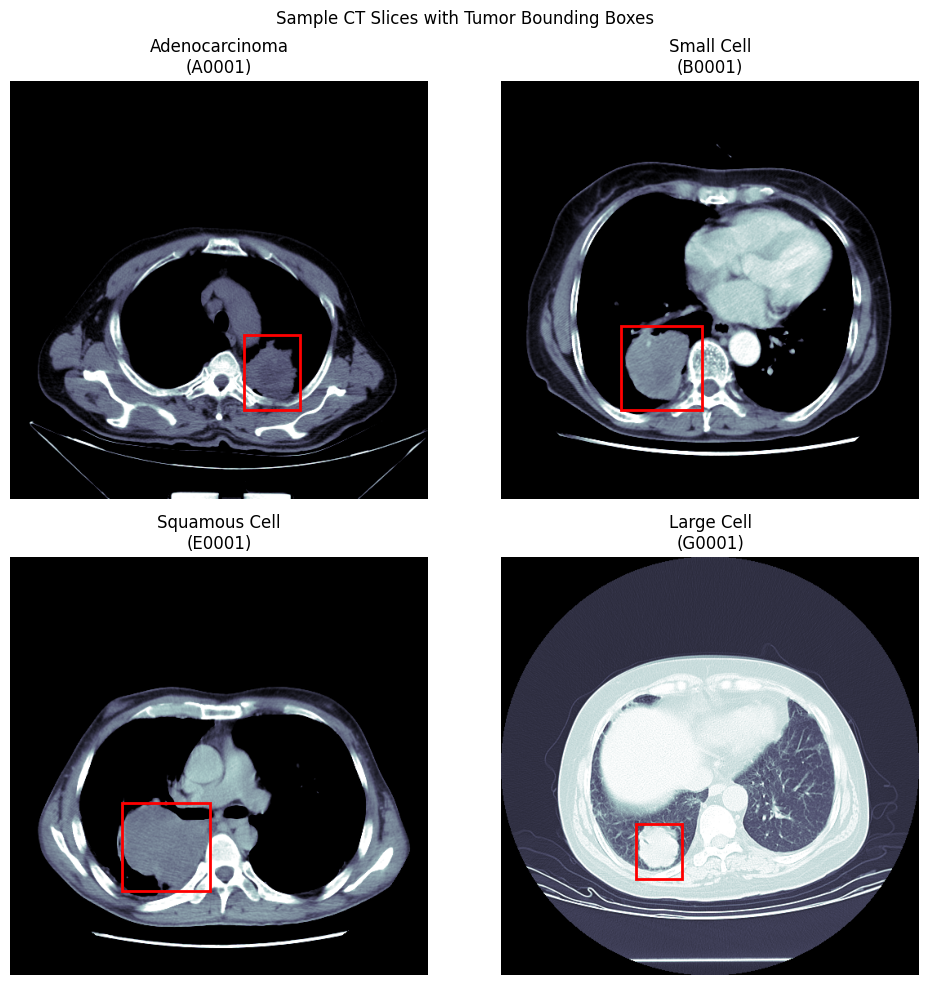

In [10]:
# load CT image from DICOM and convert to Hounsfield Units (HU)
def load_ct_image(dcm_path):
    ds = pydicom.dcmread(dcm_path)
    img = ds.pixel_array.astype(np.float32)

    # convert raw pixels to HU
    slope = getattr(ds, 'RescaleSlope', 1.0)
    intercept = getattr(ds, 'RescaleIntercept', 0.0)
    img = img * slope + intercept
    
    return img, ds


# scale HU image to 8-bit (0–255) using DICOM windowing
def hu_to_uint8(img_hu, ds=None):
    
    # initialize window parameters
    window_center = None
    window_width = None
    
    # use DICOM window properties if available
    if ds is not None:
        wc = getattr(ds, 'WindowCenter', None)
        ww = getattr(ds, 'WindowWidth', None)
        
        if wc is not None and ww is not None:

            # handle multi-value windows, use first and convert to float
            window_center = float(wc[0]) if hasattr(wc, '__getitem__') else float(wc)
            window_width = float(ww[0]) if hasattr(ww, '__getitem__') else float(ww)
    
    # apply windowing if parameters available
    if window_center is not None and window_width is not None:
        img_min = window_center - window_width / 2
        img_max = window_center + window_width / 2
    else:
        # fallback to percentile-based normalization
        img_min = np.percentile(img_hu, 1)
        img_max = np.percentile(img_hu, 99)
    
    # clip to window range
    img = np.clip(img_hu, img_min, img_max)
    
    # normalize to [0, 1]
    img_range = img_max - img_min
    if img_range > 0:
        img = (img - img_min) / img_range
    else:
        img = np.zeros_like(img)
    
    # scale to [0, 255]
    img = (img * 255).astype(np.uint8)
    return img


# extract bounding box from XML annotation file
def get_bbox_from_xml(xml_path):
    with open(xml_path, 'r', encoding='utf-8', errors='ignore') as f:
        xml_text = f.read()
    start = xml_text.find('<annotation')
    if start == -1:
        return None
    
    # convert text into xml to tree structure
    root = ET.fromstring(xml_text[start:])

    # find <bndbox> tag
    box = root.find('.//bndbox')
    if box is None:
        return None
    
    return [int(box.find(t).text) for t in ['xmin', 'ymin', 'xmax', 'ymax']]

# plot first slice from each class with bounding box
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten() 

classes = ['Adenocarcinoma', 'Small Cell', 'Squamous Cell', 'Large Cell']

for ax, cancer_type in zip(axes, classes):
    sample = matched_dt[matched_dt['cancer_type'] == cancer_type].iloc[0]
    
    # load DICOM image and convert to HU
    img, ds = load_ct_image(sample['dcm_path'])

    img = hu_to_uint8(img, ds)

    # get bounding box
    xml_path = os.path.join(anno_path, sample['patient_id'], f"{sample['sop_uid']}.xml")
    bbox = get_bbox_from_xml(xml_path)
    
    # plot with bone colormap
    ax.imshow(img, cmap='bone')
    
    # draw bounding box in red
    if bbox:
        xmin, ymin, xmax, ymax = bbox
        rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                                   linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
    
    ax.set_title(f"{cancer_type}\n({sample['patient_id']})")
    ax.axis('off')

plt.suptitle('Sample CT Slices with Tumor Bounding Boxes')
plt.tight_layout()
plt.show()

### Data Preprocessing Pipeline

In [11]:
import cv2
import random
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
from PIL import Image

# set reproducability
random.seed(42)

In [12]:
# processing pipeline
class MedicalPreprocessor:
    
    def __init__(self, target_size=256):
        self.target_size = target_size

    def preprocess(self, dcm_path, augment=False, p=0.5):

        # load and convert to HU
        img_hu, ds = load_ct_image(dcm_path)

        # apply windowing and convert to uint8
        img_uint8 = hu_to_uint8(img_hu, ds)

        # resize image
        img_final = cv2.resize(img_uint8, (self.target_size, self.target_size), interpolation=cv2.INTER_LINEAR)

        # ensure uint8 dtype and 2D shape
        if len(img_final.shape) > 2:
            img_final = img_final[:, :, 0]  # take first channel if multi-channel
        img_final = img_final.astype(np.uint8)

        # apply augmentation if requested
        if augment:
            img_final = self.augment(img_final, p=p)

        return img_final
    
    # scale bounding box to target size
    def scale_bbox(self, bbox, original_shape):
        if bbox is None:
            return None
        
        xmin, ymin, xmax, ymax = bbox
        orig_h, orig_w = original_shape[:2]
        
        scale_x = self.target_size / orig_w
        scale_y = self.target_size / orig_h
        
        return [
            int(xmin * scale_x),
            int(ymin * scale_y),
            int(xmax * scale_x),
            int(ymax * scale_y)
        ]
    
    # apply medically conservative augmentations
    # p - probability of each augmentation
    
    def augment(self, img, p=0.5):

        # convert numpy array to PIL Image
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)

        if p > 0:
            # horizontal flip
            if random.random() > 0.5:
                img = TF.hflip(img)

            # rotation ±10 degrees
            if random.random() > 0.5:
                angle = random.uniform(-10, 10)
                img = TF.rotate(img, angle, interpolation=InterpolationMode.BILINEAR)

            # brightness adjust 0.9 - 1.1
            if random.random() > 0.5:
                factor = random.uniform(0.9, 1.1)
                img = TF.adjust_brightness(img, factor)

        return np.array(img)

### Model

In [13]:
# create output directory
output_dir = 'ct_model/preprocessed_dt'
os.makedirs(output_dir, exist_ok=True)

# class mapping for YOLO
class_to_id = {
    'Adenocarcinoma': 0,
    'Small Cell': 1, 
    'Squamous Cell': 2,
    'Large Cell': 3
}

# add class ID to dataframe
matched_dt['class_id'] = matched_dt['cancer_type'].map(class_to_id)

# print total unique patient count for each disease
print('[ ] Total Patient Counts\n')
for cancer_type in ['Adenocarcinoma', 'Small Cell', 'Squamous Cell', 'Large Cell']:
    patient_count = matched_dt[matched_dt['cancer_type'] == cancer_type]['patient_id'].nunique()
    print(f'{cancer_type} : {patient_count}')

# patient-based data split to minimize leakage
# prioritize unique patients in val/test, fill with non-unique
train_indices = []
val_indices = []
test_indices = []

for cancer_type in matched_dt['cancer_type'].unique():

    # get all samples for this class
    class_dt = matched_dt[matched_dt['cancer_type'] == cancer_type].copy()
    
    # group by patient to identify unique patients
    patient_groups = class_dt.groupby('patient_id').indices
    unique_patients = list(patient_groups.keys())
    np.random.shuffle(unique_patients)
    
    total_samples = len(class_dt)
    target_val = int(0.1 * total_samples)
    target_test = int(0.1 * total_samples)
    
    # allocate unique patients to val and test first
    val_patients = []
    test_patients = []
    train_patients = []
    
    val_sample_count = 0
    test_sample_count = 0
    
    # assign patients to val until we reach target
    for patient in unique_patients:
        patient_samples = len(patient_groups[patient])
        if val_sample_count < target_val:
            val_patients.append(patient)
            val_sample_count += patient_samples
        elif test_sample_count < target_test:
            test_patients.append(patient)
            test_sample_count += patient_samples
        else:
            train_patients.append(patient)
    
    # get indices for each split based on unique patients
    val_idx = []
    test_idx = []
    train_idx = []
    
    for patient in val_patients:
        val_idx.extend(patient_groups[patient])
    
    for patient in test_patients:
        test_idx.extend(patient_groups[patient])
    
    for patient in train_patients:
        train_idx.extend(patient_groups[patient])
    
    # if val or test don't have enough samples, fill from train
    if len(val_idx) < target_val:
        shortage = target_val - len(val_idx)
        if len(train_idx) >= shortage:
            fill_idx = train_idx[:shortage]
            val_idx.extend(fill_idx)
            train_idx = train_idx[shortage:]
    
    if len(test_idx) < target_test:
        shortage = target_test - len(test_idx)
        if len(train_idx) >= shortage:
            fill_idx = train_idx[:shortage]
            test_idx.extend(fill_idx)
            train_idx = train_idx[shortage:]

    # if train has less than val, fill from val
    if len(train_idx) < len(val_idx):
        shortage = len(val_idx) - len(train_idx)
        if len(val_idx) >= shortage:
            fill_idx = val_idx[:shortage]
            train_idx.extend(fill_idx)
            val_idx = val_idx[shortage:]

    # collect global indices
    train_indices.extend(class_dt.index[train_idx].tolist())
    val_indices.extend(class_dt.index[val_idx].tolist())
    test_indices.extend(class_dt.index[test_idx].tolist())
    
    print(f'\n{cancer_type}:')
    print(f'  Unique patients in train: {len(train_patients)} ({len(train_idx)} samples)')
    print(f'  Unique patients in val: {len(val_patients)} ({len(val_idx)} samples, target: {target_val})')
    print(f'  Unique patients in test: {len(test_patients)} ({len(test_idx)} samples, target: {target_test})')

# create split dataframes
train_dt = matched_dt.loc[train_indices].reset_index(drop=True)
val_dt = matched_dt.loc[val_indices].reset_index(drop=True)
test_dt = matched_dt.loc[test_indices].reset_index(drop=True)

print(f'\n[ ] Overall Split Statistics')
print(f'Train: {len(train_dt)} samples ({len(train_dt)/len(matched_dt)*100:.1f}%)')
print(f'Val:   {len(val_dt)} samples ({len(val_dt)/len(matched_dt)*100:.1f}%)')
print(f'Test:  {len(test_dt)} samples ({len(test_dt)/len(matched_dt)*100:.1f}%)')

print(f'\n[ ] Class Distribution')
for split_name, split_df in [('Train', train_dt), ('Val', val_dt), ('Test', test_dt)]:
    print(f'\n{split_name}:')
    print(split_df['cancer_type'].value_counts().to_string())

# verify patient overlap
print(f'\n[ ] Patient Overlap')
train_patients = set(train_dt['patient_id'].unique())
val_patients = set(val_dt['patient_id'].unique())
test_patients = set(test_dt['patient_id'].unique())

print(f'Unique patients in train: {len(train_patients)}')
print(f'Unique patients in val: {len(val_patients)}')
print(f'Unique patients in test: {len(test_patients)}')

[ ] Total Patient Counts

Adenocarcinoma : 252
Small Cell : 38
Squamous Cell : 5
Large Cell : 61

Adenocarcinoma:
  Unique patients in train: 193 (10738 samples)
  Unique patients in val: 30 (1379 samples, target: 1356)
  Unique patients in test: 29 (1443 samples, target: 1356)

Small Cell:
  Unique patients in train: 29 (1584 samples)
  Unique patients in val: 1 (225 samples, target: 208)
  Unique patients in test: 8 (279 samples, target: 208)

Squamous Cell:
  Unique patients in train: 3 (79 samples)
  Unique patients in val: 1 (66 samples, target: 20)
  Unique patients in test: 1 (56 samples, target: 20)

Large Cell:
  Unique patients in train: 46 (3356 samples)
  Unique patients in val: 6 (466 samples, target: 428)
  Unique patients in test: 9 (461 samples, target: 428)

[ ] Overall Split Statistics
Train: 15757 samples (78.3%)
Val:   2136 samples (10.6%)
Test:  2239 samples (11.1%)

[ ] Class Distribution

Train:
cancer_type
Adenocarcinoma    10738
Large Cell         3356
Small Ce

In [14]:
# overall unique patient count by disease code
patient_code_counts = matched_dt.assign(
    disease_code=matched_dt['patient_id'].astype(str).str[0]
).groupby('disease_code')['patient_id'].nunique()

print('[ ] Total patients:\n')
print(f"A: {int(patient_code_counts.get('A', 0))}")
print(f"B: {int(patient_code_counts.get('B', 0))}")
print(f"G: {int(patient_code_counts.get('G', 0))}")

[ ] Total patients:

A: 252
B: 38
G: 61


In [15]:
from tqdm import tqdm

In [16]:
preprocessor = MedicalPreprocessor(target_size=128)

# save preprocessed grayscale images for each split
def save_yolo_format(df, split_name, augment=False, p=0.5):
    img_dir = os.path.join(output_dir, split_name, 'images')
    os.makedirs(img_dir, exist_ok=True)
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {split_name}"):

        # preprocess image (single channel)
        img = preprocessor.preprocess(row['dcm_path'], augment=augment, p=p)
    
        # save single-channel image
        img_filename = f"{row['patient_id']}_{row['sop_uid']}.png"
        img_path = os.path.join(img_dir, img_filename)
        cv2.imwrite(img_path, img)

# process all splits (apply augmentations only for train)
save_yolo_format(train_dt, 'train', augment=True, p=0.5)
save_yolo_format(val_dt, 'val', augment=False)
save_yolo_format(test_dt, 'test', augment=False)

Processing test: 100%|██████████| 2239/2239 [00:24<00:00, 89.67it/s]


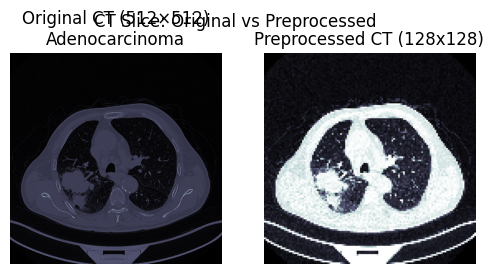

In [17]:
# get first sample from train set
sample = train_dt.iloc[0]

# preprocess (single channel only)
img = preprocessor.preprocess(sample['dcm_path'], augment=True)

# get original shape for bbox scaling
ds = pydicom.dcmread(sample['dcm_path'])
orig_shape = ds.pixel_array.shape

xml_path = os.path.join(anno_path, sample['patient_id'], f"{sample['sop_uid']}.xml")

# load original
img_hu, _ = load_ct_image(sample['dcm_path'])

# plot
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# original
axes[0].imshow(img_hu, cmap='bone')
axes[0].set_title(f'Original CT (512×512)\n{sample["cancer_type"]}')
axes[0].axis('off')

# preprocessed
axes[1].imshow(img, cmap='bone')
axes[1].set_title(f'Preprocessed CT (128x128)')
axes[1].axis('off')
plt.suptitle('CT Slice: Original vs Preprocessed')
plt.show()

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image

In [19]:
# detect device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f'Device selected: {device}')

Device selected: cuda


In [20]:
# custom dataset class for lung cancer classification
class LungCancerDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        
        # load image as grayscale
        img_filename = f"{row['patient_id']}_{row['sop_uid']}.png"
        img_path = os.path.join(self.img_dir, img_filename)
        image = Image.open(img_path).convert('L')
        
        # get label
        label = row['class_id']
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [21]:
# data transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [22]:
# create datasets
train_dataset = LungCancerDataset(train_dt, os.path.join(output_dir, 'train/images'), train_transform)
val_dataset = LungCancerDataset(val_dt, os.path.join(output_dir, 'val/images'), val_test_transform)
test_dataset = LungCancerDataset(test_dt, os.path.join(output_dir, 'test/images'), val_test_transform)

print(f'Train dataset: {len(train_dataset)} samples')
print(f'Val dataset: {len(val_dataset)} samples')
print(f'Test dataset: {len(test_dataset)} samples')

Train dataset: 15757 samples
Val dataset: 2136 samples
Test dataset: 2239 samples


In [23]:
# create dataloaders
batch_size = 4

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')

Train batches: 3940
Val batches: 534
Test batches: 560


In [24]:
# load pre-trained AlexNet model with ImageNet weights
weights = models.AlexNet_Weights.IMAGENET1K_V1
model = models.alexnet(weights=weights)

# replace only the final layer for 4 classes
num_classes = 4
model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

model = model.to(device)
print(f'Model loaded and moved to {device}')

Model loaded and moved to cuda


In [25]:
# loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

In [26]:
# training function
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc='Training'):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [27]:
# validation function
def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [28]:
# training loop
num_epochs = 30
best_val_acc = -float('inf')
best_epoch = -1
train_losses = []
val_losses = []
train_accs = []
val_accs = []

# create model save directory
model_save_dir = 'ct_model/vgg16_checkpoints'
os.makedirs(model_save_dir, exist_ok=True)

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')
    
    # learning rate scheduling
    scheduler.step(val_loss)
    
    # save best model checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'train_loss': train_loss
        }, os.path.join(model_save_dir, 'best_model.pth'))
        print(f'Best model saved with val acc: {val_acc:.2f}%')
    
    print()

print(f'Best Val Accuracy: {best_val_acc:.2f}% (Epoch {best_epoch})')

Epoch 1/30


Validation: 100%|██████████| 534/534 [00:11<00:00, 44.79it/s]


Train Loss: 0.7558 | Train Acc: 69.56%
Val Loss: 1.3798 | Val Acc: 63.58%
Best model saved with val acc: 63.58%

Epoch 2/30


Validation: 100%|██████████| 534/534 [00:03<00:00, 163.96it/s]


Train Loss: 0.5314 | Train Acc: 77.80%
Val Loss: 1.9320 | Val Acc: 51.64%

Epoch 3/30


...

Train Loss: 0.0051 | Train Acc: 99.83%
Val Loss: 6.0388 | Val Acc: 64.70%

Epoch 29/30


Validation: 100%|██████████| 534/534 [00:03<00:00, 165.14it/s]


Train Loss: 0.0068 | Train Acc: 99.76%
Val Loss: 6.0641 | Val Acc: 64.51%

Epoch 30/30


Validation: 100%|██████████| 534/534 [00:03<00:00, 161.47it/s]

Train Loss: 0.0071 | Train Acc: 99.80%
Val Loss: 5.9031 | Val Acc: 64.79%

Best Val Accuracy: 65.64% (Epoch 24)


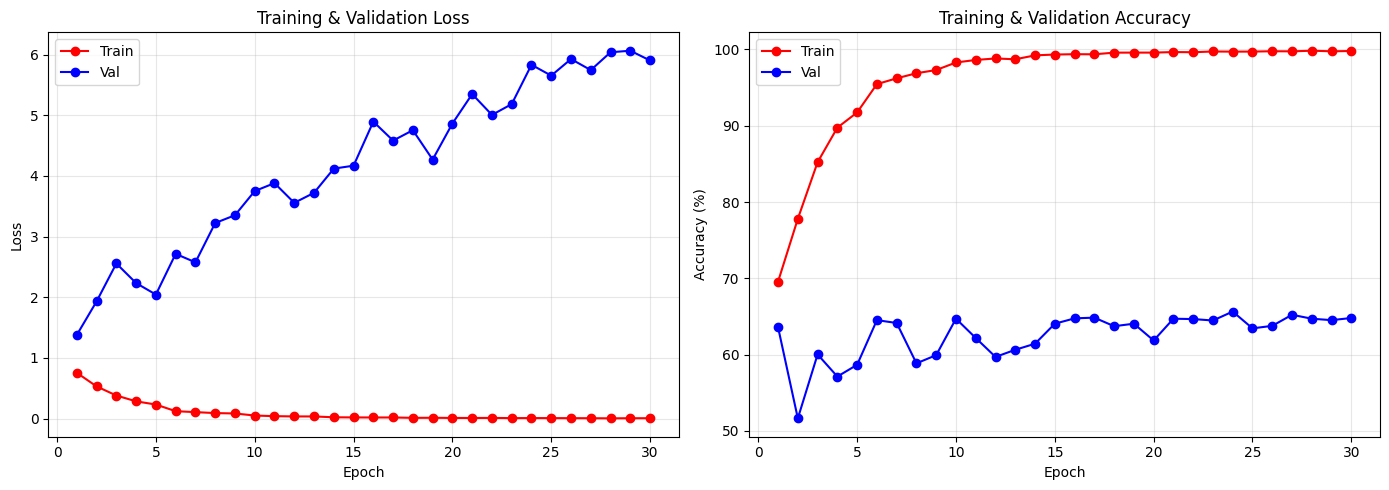

In [29]:
# plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = len(train_losses)
epoch_axis = range(1, epochs_ran + 1)

# accuracy plot
axes[1].plot(epoch_axis, train_accs, label='Train', color='red', marker='o')
axes[1].plot(epoch_axis, val_accs, label='Val', color='blue', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

# loss plot
axes[0].plot(epoch_axis, train_losses, label='Train', color='red', marker='o')
axes[0].plot(epoch_axis, val_losses, label='Val', color='blue', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Classification Results (Test Dataset)

In [30]:
# load best model
checkpoint = torch.load(os.path.join(model_save_dir, 'best_model.pth'))
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"Best validation accuracy: {checkpoint['val_acc']:.2f}%")

Loaded best model from epoch 24
Best validation accuracy: 65.64%


In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

In [32]:
# evaluate on validation set
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc='Validation'):
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print('\n[ ] Overall Classification Metrics (Validation)\n')
print(f'  Accuracy:  {accuracy:.4f}')
print(f'  Precision: {precision:.4f}')
print(f'  Recall:    {recall:.4f}')
print(f'  F1-Score:  {f1:.4f}')

Validation: 100%|██████████| 534/534 [00:03<00:00, 164.29it/s]


[ ] Overall Classification Metrics (Validation)

  Accuracy:  0.6564
  Precision: 0.6016
  Recall:    0.6564
  F1-Score:  0.6259


In [33]:
# per-class metrics
class_names = ['Adenocarcinoma', 'Small Cell', 'Squamous Cell', 'Large Cell']

print('\n[ ] Per-Class Classification Metrics\n')
for i, class_name in enumerate(class_names):
    mask = y_true == i
    if mask.sum() > 0:
        class_acc = (y_pred[mask] == i).sum() / mask.sum()
        class_prec = precision_score(y_true == i, y_pred == i, zero_division=0)
        class_rec = recall_score(y_true == i, y_pred == i, zero_division=0)
        class_f1 = f1_score(y_true == i, y_pred == i, zero_division=0)
        
        print(f'{class_name}:')
        print(f'  Accuracy:  {class_acc:.4f}')
        print(f'  Precision: {class_prec:.4f}')
        print(f'  Recall:    {class_rec:.4f}')
        print(f'  F1-Score:  {class_f1:.4f}')
        print()


[ ] Per-Class Classification Metrics

Adenocarcinoma:
  Accuracy:  0.8622
  Precision: 0.7516
  Recall:    0.8622
  F1-Score:  0.8031

Small Cell:
  Accuracy:  0.0000
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

Squamous Cell:
  Accuracy:  0.8636
  Precision: 1.0000
  Recall:    0.8636
  F1-Score:  0.9268

Large Cell:
  Accuracy:  0.3348
  Precision: 0.3920
  Recall:    0.3348
  F1-Score:  0.3611



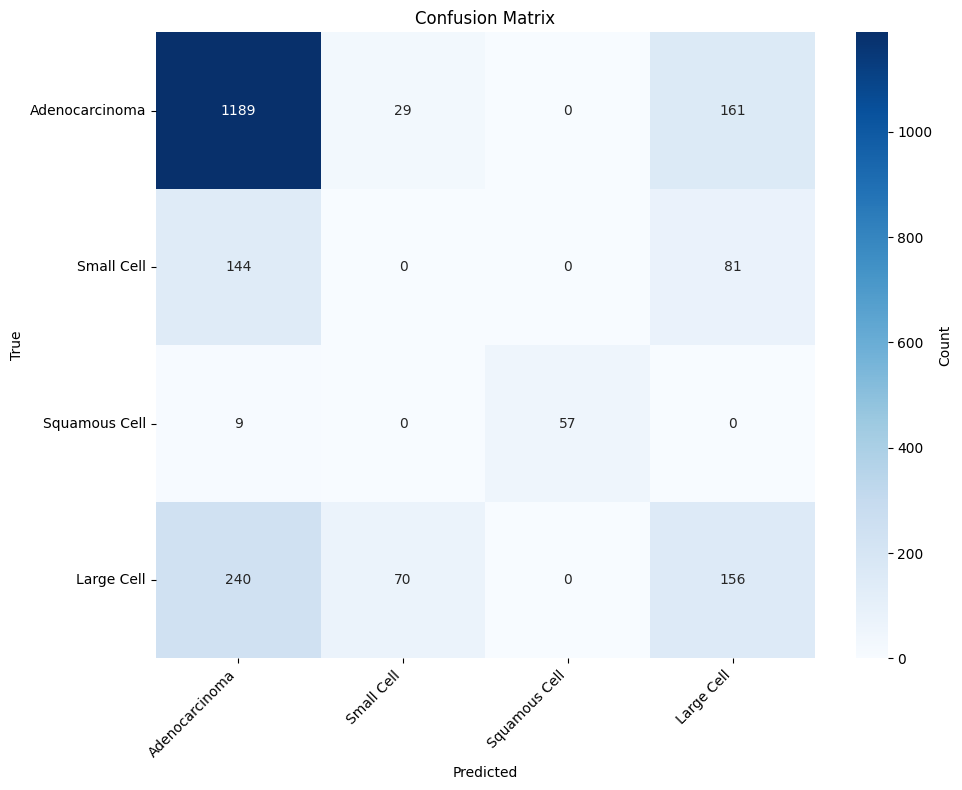

In [34]:
# confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

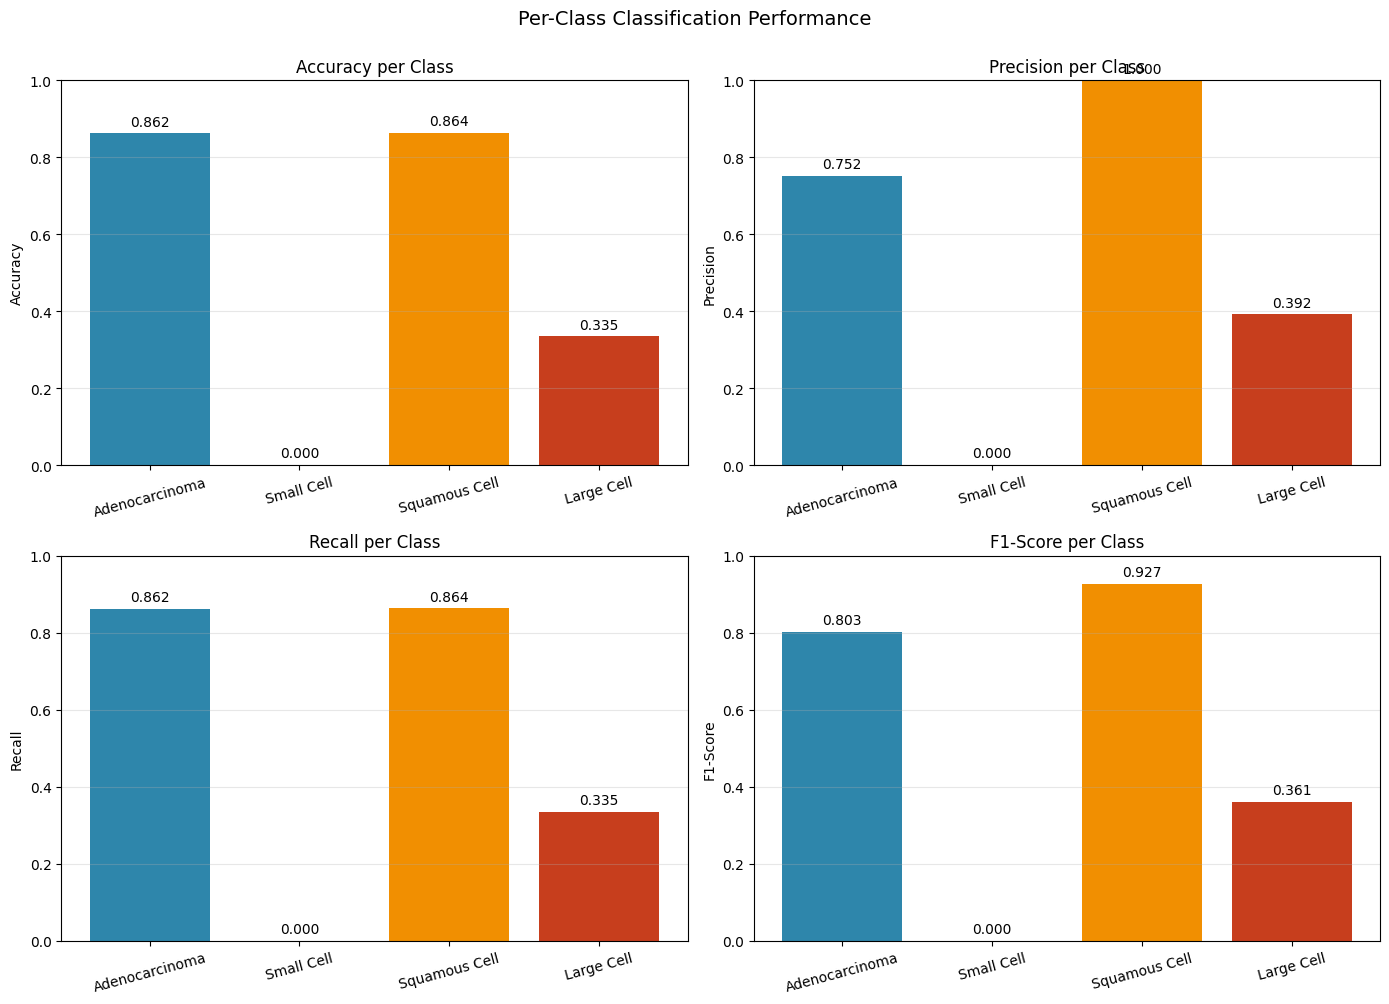

In [35]:
# per-class metrics visualization
class_accuracy_values = []
class_precision_values = []
class_recall_values = []
class_f1_values = []

for i, class_name in enumerate(class_names):
    mask = y_true == i
    if mask.sum() > 0:
        class_acc = (y_pred[mask] == i).sum() / mask.sum()
        class_prec = precision_score(y_true == i, y_pred == i, zero_division=0)
        class_rec = recall_score(y_true == i, y_pred == i, zero_division=0)
        class_f1 = f1_score(y_true == i, y_pred == i, zero_division=0)
    else:
        class_acc = 0.0
        class_prec = 0.0
        class_rec = 0.0
        class_f1 = 0.0
    
    class_accuracy_values.append(class_acc)
    class_precision_values.append(class_prec)
    class_recall_values.append(class_rec)
    class_f1_values.append(class_f1)

# color palette
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].bar(class_names, class_accuracy_values, color=colors)
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Accuracy per Class')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_accuracy_values):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[0, 0].tick_params(axis='x', rotation=15)

# Precision
axes[0, 1].bar(class_names, class_precision_values, color=colors)
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision per Class')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_precision_values):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[0, 1].tick_params(axis='x', rotation=15)

# Recall
axes[1, 0].bar(class_names, class_recall_values, color=colors)
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_title('Recall per Class')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_recall_values):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[1, 0].tick_params(axis='x', rotation=15)

# F1-Score
axes[1, 1].bar(class_names, class_f1_values, color=colors)
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].set_title('F1-Score per Class')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_f1_values):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.suptitle('Per-Class Classification Performance', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

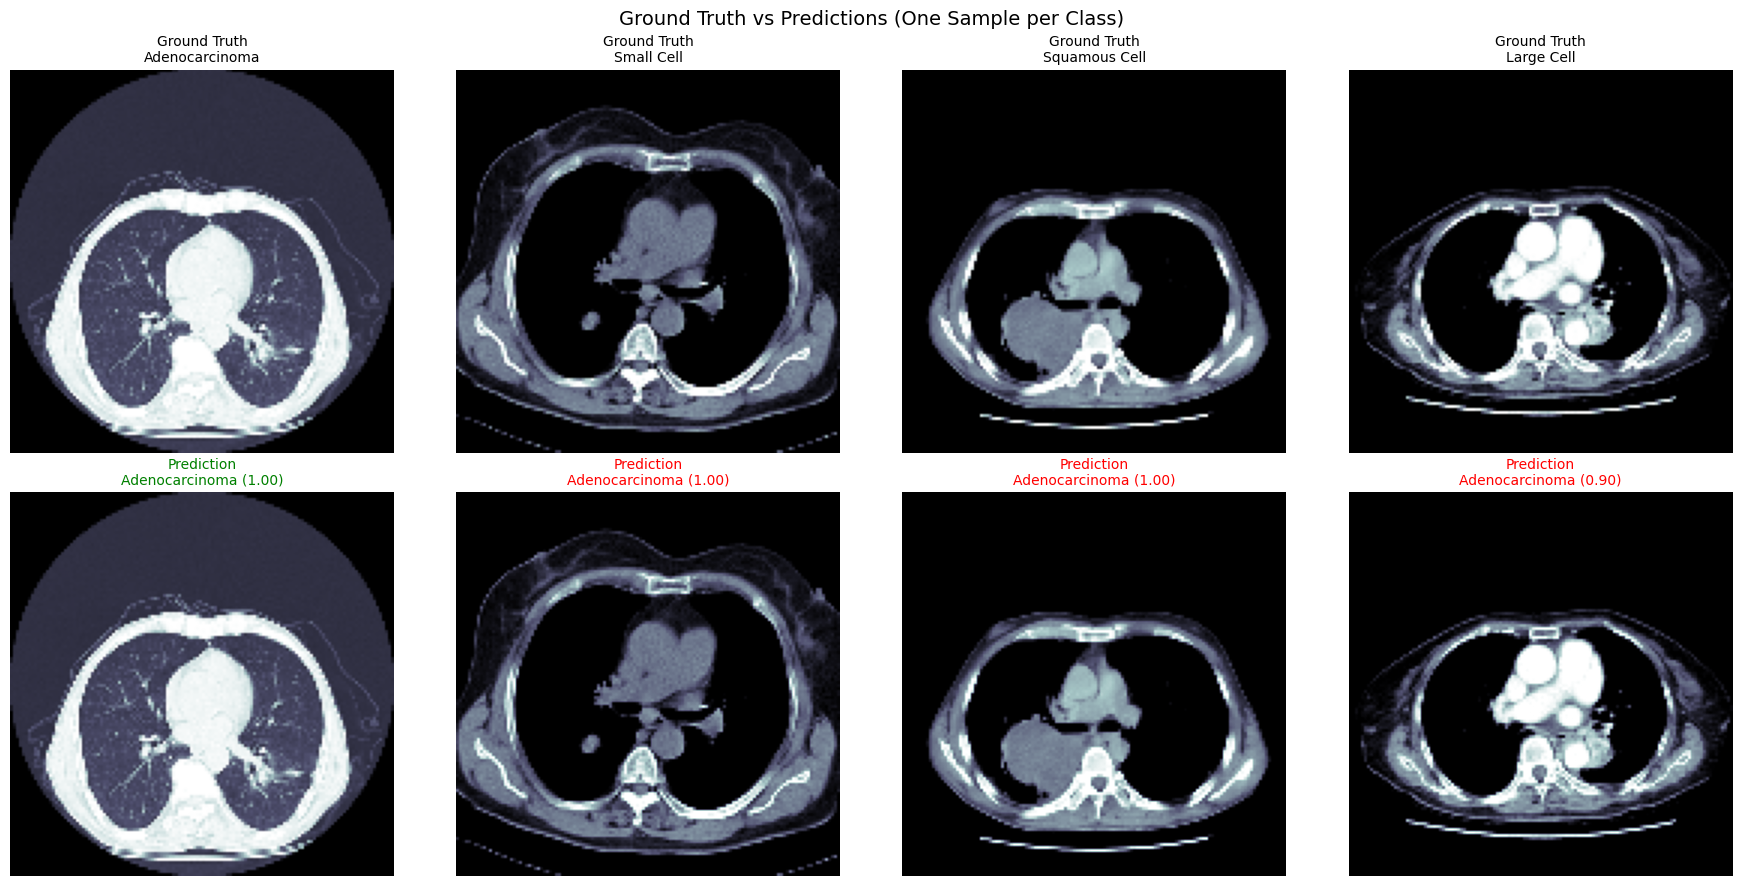

In [36]:
# visualize sample predictions
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

model.eval()
with torch.no_grad():
    for class_id, class_name in enumerate(class_names):
        # find sample from this class
        class_samples = test_dt[test_dt['class_id'] == class_id]
        if len(class_samples) == 0:
            continue
        
        sample = class_samples.iloc[0]
        
        # image path
        img_filename = f"{sample['patient_id']}_{sample['sop_uid']}.png"
        img_path = os.path.join(output_dir, 'test/images', img_filename)
        
        # load and preprocess image
        img_display = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img_pil = Image.open(img_path).convert('L')
        img_tensor = val_test_transform(img_pil).unsqueeze(0).to(device)
        
        # predict
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_class = output.argmax(1).item()
        pred_conf = probs[0, pred_class].item()
        
        # ground truth
        gt_class = sample['class_id']
        
        # plot ground truth
        ax_gt = axes[0, class_id]
        ax_gt.imshow(img_display, cmap='bone')
        ax_gt.set_title(f'Ground Truth\n{class_name}', fontsize=10)
        ax_gt.axis('off')
        
        # plot prediction
        ax_pred = axes[1, class_id]
        ax_pred.imshow(img_display, cmap='bone')
        color = 'green' if pred_class == gt_class else 'red'
        ax_pred.set_title(f'Prediction\n{class_names[pred_class]} ({pred_conf:.2f})', 
                          fontsize=10, color=color)
        ax_pred.axis('off')

plt.suptitle('Ground Truth vs Predictions (One Sample per Class)', fontsize=14)
plt.tight_layout()
plt.show()

In [37]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

In [38]:
model.eval()
y_true_prob = []
y_scores = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Computing probabilities'):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        
        y_true_prob.extend(labels.cpu().numpy())
        y_scores.extend(probs.cpu().numpy())

y_true_prob = np.array(y_true_prob)
y_scores = np.array(y_scores)

# binarize the labels for multi-class ROC/PR curves
y_true_bin = label_binarize(y_true_prob, classes=[0, 1, 2, 3])
n_classes = len(class_names)

Computing probabilities: 100%|██████████| 560/560 [00:12<00:00, 44.32it/s]


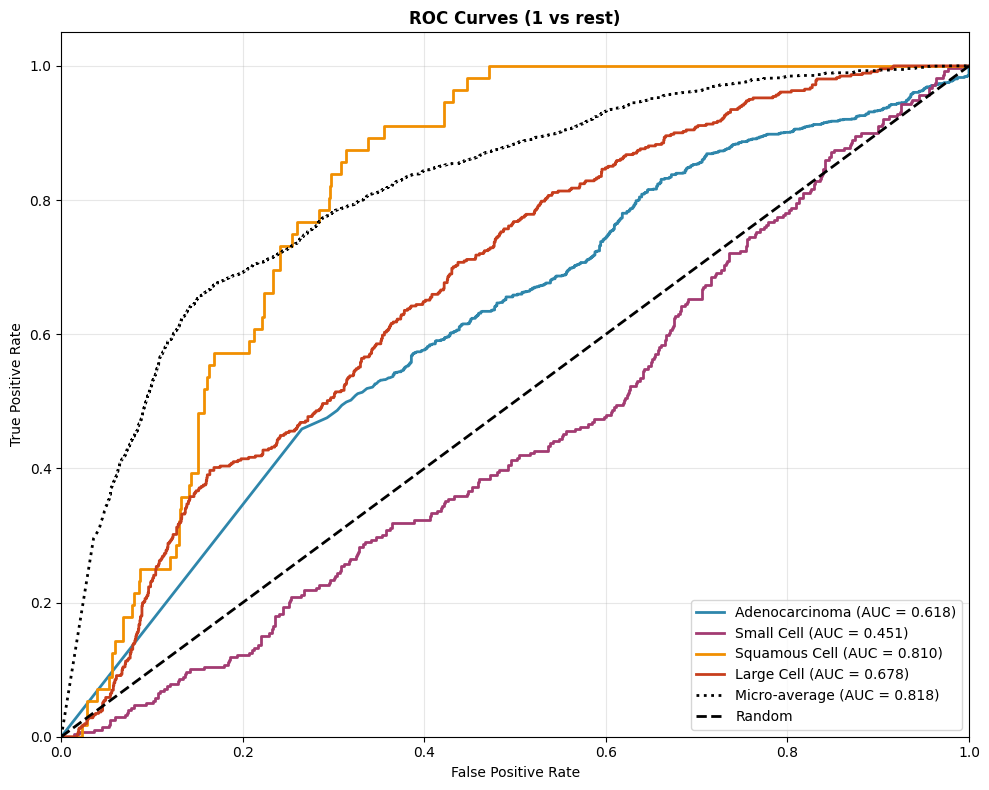


[ ] AUROC (Area Under ROC Curve)

Adenocarcinoma: 0.6182
Small Cell: 0.4511
Squamous Cell: 0.8098
Large Cell: 0.6778

Macro-average AUROC: 0.6392
Micro-average AUROC: 0.8178


In [39]:
# plot AUROC curves for each class
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
roc_auc = {}

for i, (class_name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[class_name] = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, 
            label=f'{class_name} (AUC = {roc_auc[class_name]:.3f})')

# micro-average ROC
fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

# plot micro-average curve
ax.plot(
    fpr_micro,
    tpr_micro,
    color='black',
    lw=2,
    linestyle=':',
    label=f'Micro-average (AUC = {roc_auc_micro:.3f})'
 )

# plot diagonal line
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (1 vs rest)', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

# print AUC values
print('\n[ ] AUROC (Area Under ROC Curve)\n')
for class_name in class_names:
    print(f'{class_name}: {roc_auc[class_name]:.4f}')
print(f'\nMacro-average AUROC: {np.mean(list(roc_auc.values())):.4f}')
print(f'Micro-average AUROC: {roc_auc_micro:.4f}')

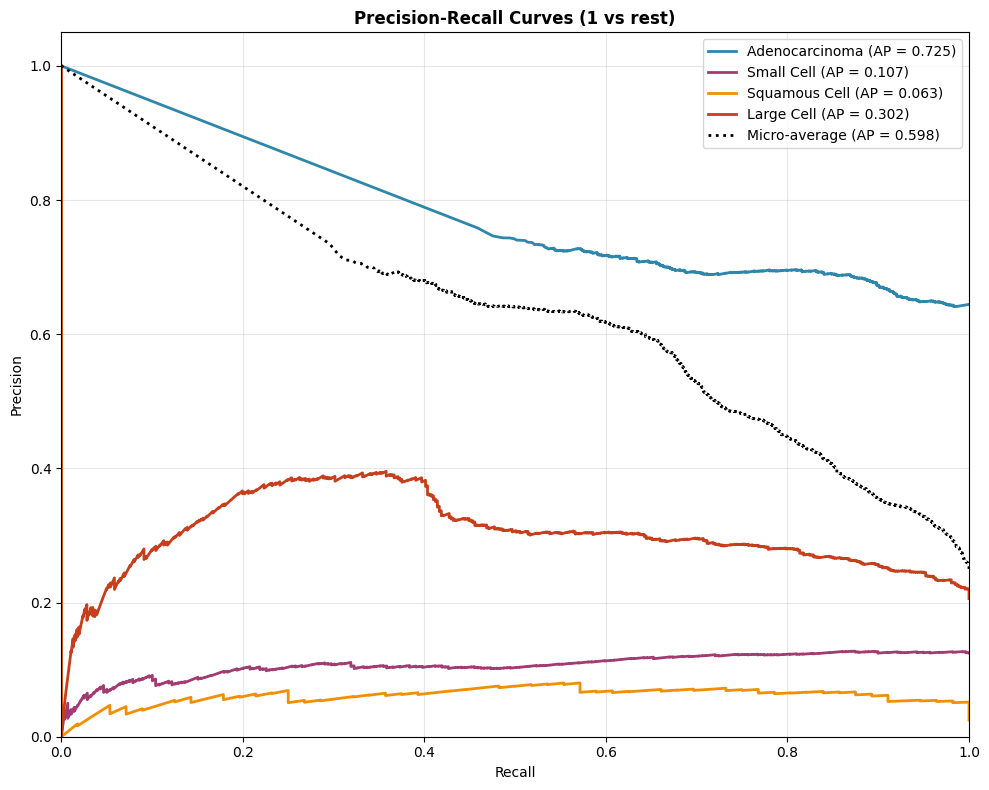


[ ] AUPRC (Area Under Precision-Recall Curve)

Adenocarcinoma: 0.7253
Small Cell: 0.1073
Squamous Cell: 0.0627
Large Cell: 0.3018

Macro-average AUPRC: 0.2993
Micro-average AUPRC: 0.5979


In [40]:
# plot AUPRC (Precision-Recall) curves for each class
fig, ax = plt.subplots(figsize=(10, 8))

pr_auc = {}

for i, (class_name, color) in enumerate(zip(class_names, colors)):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_scores[:, i])
    pr_auc[class_name] = average_precision_score(y_true_bin[:, i], y_scores[:, i])
    ax.plot(recall, precision, color=color, lw=2, 
            label=f'{class_name} (AP = {pr_auc[class_name]:.3f})')

# micro-average PR
precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_scores.ravel())
pr_auc_micro = average_precision_score(y_true_bin, y_scores, average='micro')

# plot micro-average curve
ax.plot(
    recall_micro,
    precision_micro,
    color='black',
    lw=2,
    linestyle=':',
    label=f'Micro-average (AP = {pr_auc_micro:.3f})'
 )

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (1 vs rest)', fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

# print AP values
print('\n[ ] AUPRC (Area Under Precision-Recall Curve)\n')
for class_name in class_names:
    print(f'{class_name}: {pr_auc[class_name]:.4f}')
print(f'\nMacro-average AUPRC: {np.mean(list(pr_auc.values())):.4f}')
print(f'Micro-average AUPRC: {pr_auc_micro:.4f}')

In [41]:
# find optimal thresholds for each class to maximize F1 score on validation set

# get model predictions (probabilities) for validation set
model.eval()
y_val_true = []
y_val_scores = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc='Validation Threshold Search'):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        y_val_true.extend(labels.cpu().numpy())
        y_val_scores.extend(probs.cpu().numpy())

y_val_true = np.array(y_val_true)
y_val_scores = np.array(y_val_scores)

# Find best threshold for each class
best_thresholds = []
best_f1s = []
class_names = ['Adenocarcinoma', 'Small Cell', 'Squamous Cell', 'Large Cell']
for i, class_name in enumerate(class_names):
    precision, recall, thresholds = precision_recall_curve((y_val_true == i).astype(int), y_val_scores[:, i])
    f1s = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.nanargmax(f1s)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_f1 = f1s[best_idx]
    best_thresholds.append(best_threshold)
    best_f1s.append(best_f1)
    print(f"Class {class_name}: Best threshold = {best_threshold:.3f}, F1 = {best_f1:.3f}")

# Apply optimal thresholds to validation predictions
y_val_pred = []
for row in y_val_scores:
    pred = [row[i] > best_thresholds[i] for i in range(len(class_names))]
    if sum(pred) == 1:
        y_val_pred.append(np.argmax(pred))
    else:
        y_val_pred.append(np.argmax(row))  # fallback to max prob if ambiguous

y_val_pred = np.array(y_val_pred)


Validation Threshold Search: 100%|██████████| 534/534 [00:03<00:00, 160.76it/s]

Class Adenocarcinoma: Best threshold = 0.000, F1 = 0.814
Class Small Cell: Best threshold = 0.000, F1 = 0.238
Class Squamous Cell: Best threshold = 0.003, F1 = 0.977
Class Large Cell: Best threshold = 0.075, F1 = 0.415


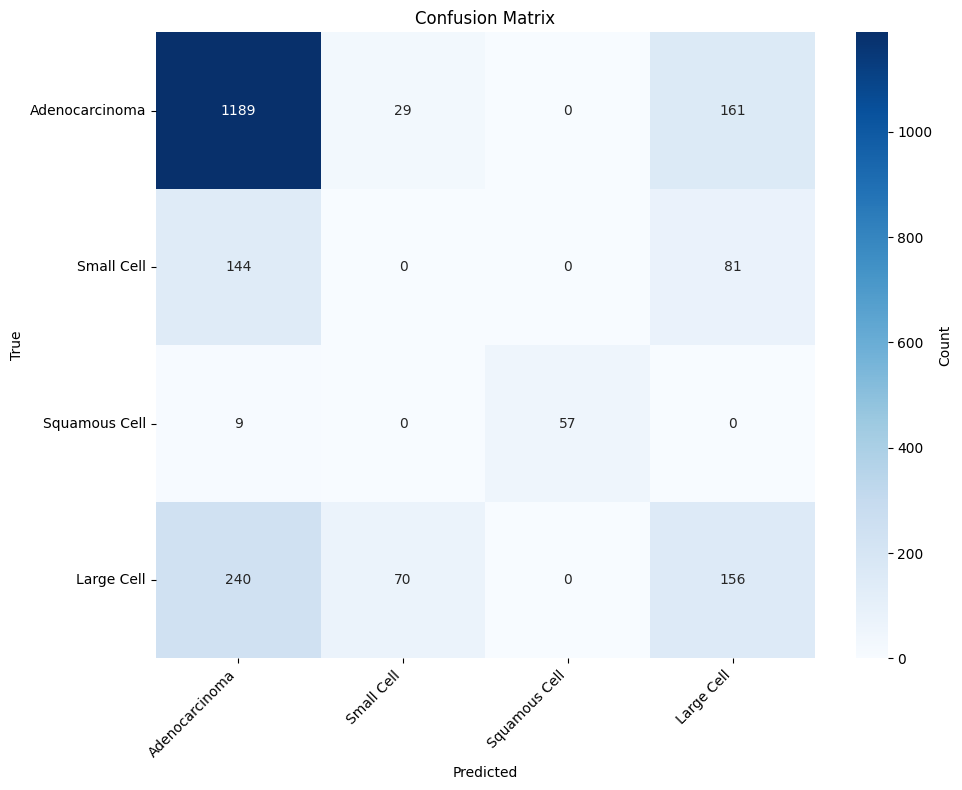

In [42]:
#  onfusion matrix for validation set with optimal thresholds
cm_val = confusion_matrix(y_val_true, y_val_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()